In [ ]:
from google.colab import files
import pandas as pd

print("Upload PID_files.csv file:")
uploaded = files.upload()



# Load the datasets
df_sensor = pd.read_csv('PID_files.csv', on_bad_lines='skip')


print("Files loaded successfully!")
print(f"Sensor data shape: {df_sensor.shape}")

Upload PID_files.csv file:


Saving PID_files.csv to PID_files (2).csv
Files loaded successfully!
Sensor data shape: (136178, 31)


In [ ]:
# ============================================
# COMPLETE PREPROCESSING CODE
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the data (if not already loaded)
df = pd.read_csv('PID_files.csv', on_bad_lines='skip')

# Clean column names by stripping whitespace
df.columns = df.columns.str.strip()

print("="*60)
print("STEP 1: Initial Data Exploration")
print("="*60)
print(f"Original dataset shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")
print("\nFirst 5 rows:")
print(df.head())
print("\nMissing values per column:")
print(df.isnull().sum())

# ============================================
# STEP 2: Extract Only Required Columns
# ============================================

required_columns = ['AccX','AccY','AccZ','GyroX','GyroY','GyroZ','Features']
available_columns = [col for col in required_columns if col in df.columns]

print("\n" + "="*60)
print("STEP 2: Extracting Required Columns")
print("="*60)
print(f"Available columns: {available_columns}")

# Extract only needed columns
df_selected = df[available_columns].copy()
print(f"\nExtracted data shape: {df_selected.shape}")

# ============================================
# STEP 3: Handle Missing Values
# ============================================

print("\n" + "="*60)
print("STEP 3: Handling Missing Values")
print("="*60)

# Check for missing values
print(f"Missing values before cleaning:\n{df_selected.isnull().sum()}")

# Ensure sensor columns are numeric and then remove rows with any missing values in sensor columns
sensor_cols = ['AccX', 'AccY', 'AccZ', 'GyroX', 'GyroY', 'GyroZ']
for col in sensor_cols:
    df_selected[col] = pd.to_numeric(df_selected[col], errors='coerce')
df_selected = df_selected.dropna(subset=sensor_cols)

print(f"Shape after dropping missing values: {df_selected.shape}")

# ============================================
# STEP 4: Convert Labels to Binary (Fall = 1, Normal = 0)
# ============================================

print("\n" + "="*60)
print("STEP 4: Converting Labels to Binary")
print("="*60)

# See all unique labels
print("Unique labels in Features column:")
print(df_selected['Features'].unique())

# Create binary label column
def convert_label(label):
    if pd.isna(label):
        return 0
    label_str = str(label).lower()
    if 'fall' in label_str:
        return 1  # Fall detected
    else:
        return 0  # Normal activity

df_selected['Label'] = df_selected['Features'].apply(convert_label)

# Check class distribution
print("\nClass distribution:")
print(df_selected['Label'].value_counts())
print(f"Normal samples: {(df_selected['Label']==0).sum()}")
print(f"Fall samples: {(df_selected['Label']==1).sum()}")

# Create a readable activity column
df_selected['Activity'] = df_selected['Features']

# ============================================
# STEP 5: Clean Sensor Data (Remove Outliers)
# ============================================

print("\n" + "="*60)
print("STEP 5: Removing Outliers")
print("="*60)

def remove_outliers(df, columns, threshold=3):
    """Remove outliers using Z-score method"""
    df_clean = df.copy()
    for col in columns:
        z_scores = np.abs((df_clean[col] - df_clean[col].mean()) / df_clean[col].std())
        df_clean = df_clean[z_scores < threshold]
    return df_clean

# Remove outliers from sensor data
df_clean = remove_outliers(df_selected, sensor_cols, threshold=4)
print(f"Shape before outlier removal: {df_selected.shape}")
print(f"Shape after outlier removal: {df_clean.shape}")

# ============================================
# STEP 6: Save to Excel File
# ============================================

print("\n" + "="*60)
print("STEP 6: Saving to Excel")
print("="*60)

# Create final dataframe with desired columns
final_df = df_clean[['AccX', 'AccY', 'AccZ', 'GyroX', 'GyroY', 'GyroZ', 'Label', 'Activity']].copy()

# Save to Excel
excel_filename = 'fall_detection_dataset.xlsx'
final_df.to_excel(excel_filename, index=False)

print(f"Dataset saved as: {excel_filename}")
print(f"Final dataset shape: {final_df.shape}")
print("\nFirst 10 rows of final dataset:")
print(final_df.head(10))

# Download the Excel file in Colab
from google.colab import files
files.download(excel_filename)

print(f"\n✅ Dataset ready! Downloaded as {excel_filename}")

STEP 1: Initial Data Exploration
Original dataset shape: (136178, 31)
Columns: ['Datetime', 'ECGR', 'AvgECG', 'ampECG', 'MAX', 'GSRR', 'Resistance', 'GSR(kohm)', 'SCL', 'GSRRMS', 'GSRMAV', 'EMGR', 'EMGRMS', 'EMGMAV', 'EMGVAR', 'EMGSSI', 'IEMG', 'AccX', 'AccY', 'AccZ', 'GyroX', 'GyroY', 'GyroZ', 'Aroll', 'Apitch', 'Groll', 'Gpitch', 'Gy', 'Combroll', 'Combpitch', 'Features']

First 5 rows:
  Datetime ECGR AvgECG  ampECG  MAX GSRR Resistance GSR(kohm)   SCL GSRRMS  \
0  07:04.0  741    741  1111.5  741  576       0.78   1288.59  2.82      0   
1  07:04.1  744    742    1113  744  581       0.76   1314.48  2.84      0   
2  07:04.2  577    687  1030.5  744  577       0.77   1293.72  2.82      0   
3  07:04.4  148    552     828  744  576       0.78   1288.59  2.82      0   
4  07:04.5  383    518     777  744  572       0.79   1268.29   2.8      0   

   ...  GyroY  GyroZ  Aroll  Apitch  Groll Gpitch     Gy Combroll Combpitch  \
0  ...   0.16  -0.76  -6.14  -82.86  -0.43  -0.39  -0.18    

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


✅ Dataset ready! Downloaded as fall_detection_dataset.xlsx


DATA PREPARATION FOR TRAINING
Features shape: (124997, 6)
Labels shape: (124997,)
Class distribution:
  Normal (0): 117742
  Fall (1): 7255

Training set size: 99997 samples
Test set size: 25000 samples

TRAINING AND EVALUATING MODELS

Decision Tree:
  Accuracy: 0.9535 (95.35%)
  F1-Score: 0.6093

Random Forest:
  Accuracy: 0.9728 (97.28%)
  F1-Score: 0.7116

Gradient Boosting:
  Accuracy: 0.9712 (97.12%)
  F1-Score: 0.6926

SVM:
  Accuracy: 0.9719 (97.19%)
  F1-Score: 0.6932

Neural Network:
  Accuracy: 0.9718 (97.18%)
  F1-Score: 0.7121

MODEL COMPARISON SUMMARY
            Model  Accuracy  F1-Score
    Random Forest   0.97280  0.711620
              SVM   0.97192  0.693182
   Neural Network   0.97176  0.712072
Gradient Boosting   0.97124  0.692604
    Decision Tree   0.95352  0.609280

HYPERPARAMETER TUNING FOR BEST MODEL
Fitting 5 folds for each of 108 candidates, totalling 540 fits

Best parameters: {'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 10, 'n_estimators': 

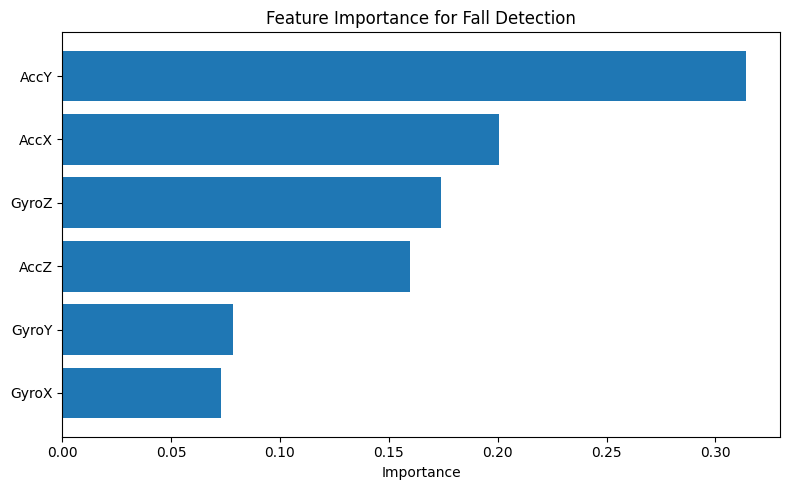


FINAL VERDICT
✅ SUCCESS! Achieved >90% accuracy with selected columns only!
   Final Accuracy: 97.26%

MODEL SAVED FOR ESP32 DEPLOYMENT
Model saved as: fall_detection_model.pkl
Scaler saved as: scaler.pkl


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# ============================================
# TRAINING MULTIPLE AI MODELS
# ============================================

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
import warnings
warnings.filterwarnings('ignore')

# Load the dataset
df = pd.read_excel('fall_detection_dataset.xlsx')

print("="*60)
print("DATA PREPARATION FOR TRAINING")
print("="*60)

# Prepare features (X) and labels (y)
feature_columns = ['AccX', 'AccY', 'AccZ', 'GyroX', 'GyroY', 'GyroZ']
X = df[feature_columns].values
y = df['Label'].values

print(f"Features shape: {X.shape}")
print(f"Labels shape: {y.shape}")
print(f"Class distribution:\n  Normal (0): {(y==0).sum()}\n  Fall (1): {(y==1).sum()}")

# Split data (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nTraining set size: {X_train.shape[0]} samples")
print(f"Test set size: {X_test.shape[0]} samples")

# Standardize features (important for SVM and Neural Network)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ============================================
# TRAIN DIFFERENT MODELS
# ============================================

models = {
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42, n_estimators=100),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42),
    'SVM': SVC(kernel='rbf', random_state=42),
    'Neural Network': MLPClassifier(hidden_layer_sizes=(64, 32), random_state=42, max_iter=500)
}

print("\n" + "="*60)
print("TRAINING AND EVALUATING MODELS")
print("="*60)

results = []

for name, model in models.items():
    # Train the model
    if name in ['SVM', 'Neural Network']:
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    results.append({
        'Model': name,
        'Accuracy': accuracy,
        'F1-Score': f1
    })

    print(f"\n{name}:")
    print(f"  Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")
    print(f"  F1-Score: {f1:.4f}")

# Create results dataframe
results_df = pd.DataFrame(results)
results_df = results_df.sort_values('Accuracy', ascending=False)

print("\n" + "="*60)
print("MODEL COMPARISON SUMMARY")
print("="*60)
print(results_df.to_string(index=False))

# ============================================
# FIND BEST MODEL WITH HYPERPARAMETER TUNING
# ============================================

print("\n" + "="*60)
print("HYPERPARAMETER TUNING FOR BEST MODEL")
print("="*60)

# Random Forest usually works best for fall detection
rf = RandomForestClassifier(random_state=42)

# Define parameter grid
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [10, 20, 30, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# Grid search with cross-validation
grid_search = GridSearchCV(
    rf, param_grid, cv=5, scoring='accuracy', n_jobs=-1, verbose=1
)
grid_search.fit(X_train, y_train)

print(f"\nBest parameters: {grid_search.best_params_}")
print(f"Best cross-validation accuracy: {grid_search.best_score_:.4f}")

# Evaluate best model on test set
best_rf = grid_search.best_estimator_
y_pred_best = best_rf.predict(X_test)
best_accuracy = accuracy_score(y_test, y_pred_best)
best_f1 = f1_score(y_test, y_pred_best)

print(f"\nBest Random Forest on Test Set:")
print(f"  Accuracy: {best_accuracy:.4f} ({best_accuracy*100:.2f}%)")
print(f"  F1-Score: {best_f1:.4f}")

# ============================================
# CONFUSION MATRIX
# ============================================

print("\n" + "="*60)
print("CONFUSION MATRIX")
print("="*60)

cm = confusion_matrix(y_test, y_pred_best)
print("                 Predicted")
print("               Normal   Fall")
print(f"Actual Normal    {cm[0,0]:5d}   {cm[0,1]:5d}")
print(f"       Fall       {cm[1,0]:5d}   {cm[1,1]:5d}")

# Calculate detailed metrics
tn, fp, fn, tp = cm.ravel()
sensitivity = tp / (tp + fn)  # Recall for fall class
specificity = tn / (tn + fp)  # Recall for normal class
precision = tp / (tp + fp)

print(f"\nDetailed Metrics:")
print(f"  Sensitivity (True Fall Rate): {sensitivity:.4f} ({sensitivity*100:.2f}%)")
print(f"  Specificity (True Normal Rate): {specificity:.4f} ({specificity*100:.2f}%)")
print(f"  Precision (Fall detection accuracy): {precision:.4f} ({precision*100:.2f}%)")

# ============================================
# FEATURE IMPORTANCE
# ============================================

print("\n" + "="*60)
print("FEATURE IMPORTANCE")
print("="*60)

feature_importance = pd.DataFrame({
    'Feature': feature_columns,
    'Importance': best_rf.feature_importances_
}).sort_values('Importance', ascending=False)

print(feature_importance.to_string(index=False))

# Plot feature importance
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 5))
plt.barh(feature_importance['Feature'], feature_importance['Importance'])
plt.xlabel('Importance')
plt.title('Feature Importance for Fall Detection')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('feature_importance.png')
plt.show()

# ============================================
# FINAL VERDICT
# ============================================

print("\n" + "="*60)
print("FINAL VERDICT")
print("="*60)

if best_accuracy >= 0.90:
    print("✅ SUCCESS! Achieved >90% accuracy with selected columns only!")
    print(f"   Final Accuracy: {best_accuracy*100:.2f}%")
else:
    print(f"⚠️ Current accuracy: {best_accuracy*100:.2f}%")
    print("   Suggestions to improve:")
    print("   1. Add more data (windowed sequences instead of single points)")
    print("   2. Include Gyroscope features (already included)")
    print("   3. Try adding rolling averages of sensor data")

print("\n" + "="*60)
print("MODEL SAVED FOR ESP32 DEPLOYMENT")
print("="*60)

# Save the best model
import joblib
joblib.dump(best_rf, 'fall_detection_model.pkl')
joblib.dump(scaler, 'scaler.pkl')

print("Model saved as: fall_detection_model.pkl")
print("Scaler saved as: scaler.pkl")

# Download model files
files.download('fall_detection_model.pkl')
files.download('scaler.pkl')

DATA PREPARATION FOR TRAINING
Total dataset shape: (124997, 6)
Total samples: 124997

📊 TOTAL DATASET CLASS DISTRIBUTION:
   Normal (0): 117742 samples (94.20%)
   Fall (1):   7255 samples (5.80%)

📊 TRAIN SET (80% of data):
   Total samples: 99997
   Normal (0): 94193 samples
   Fall (1):   5804 samples

📊 TEST SET (20% of data):
   Total samples: 25000
   Normal (0): 23549 samples
   Fall (1):   1451 samples

TRAINING AND EVALUATING MODELS (TRAIN SET vs TEST SET)

📊 MODEL: Decision Tree

📈 TRAIN SET RESULTS:
   Accuracy:  1.0000 (100.00%)
   Precision: 1.0000 (100.00%)
   Recall:    1.0000 (100.00%)
   F1-Score:  1.0000

📉 TEST SET RESULTS:
   Accuracy:  0.9535 (95.35%)
   Precision: 0.5949 (59.49%)
   Recall:    0.6244 (62.44%)
   F1-Score:  0.6093

✅ Good generalization! (Train-Test gap: 0.0465)

📊 MODEL: Random Forest

📈 TRAIN SET RESULTS:
   Accuracy:  1.0000 (100.00%)
   Precision: 1.0000 (100.00%)
   Recall:    1.0000 (100.00%)
   F1-Score:  1.0000

📉 TEST SET RESULTS:
   Accur

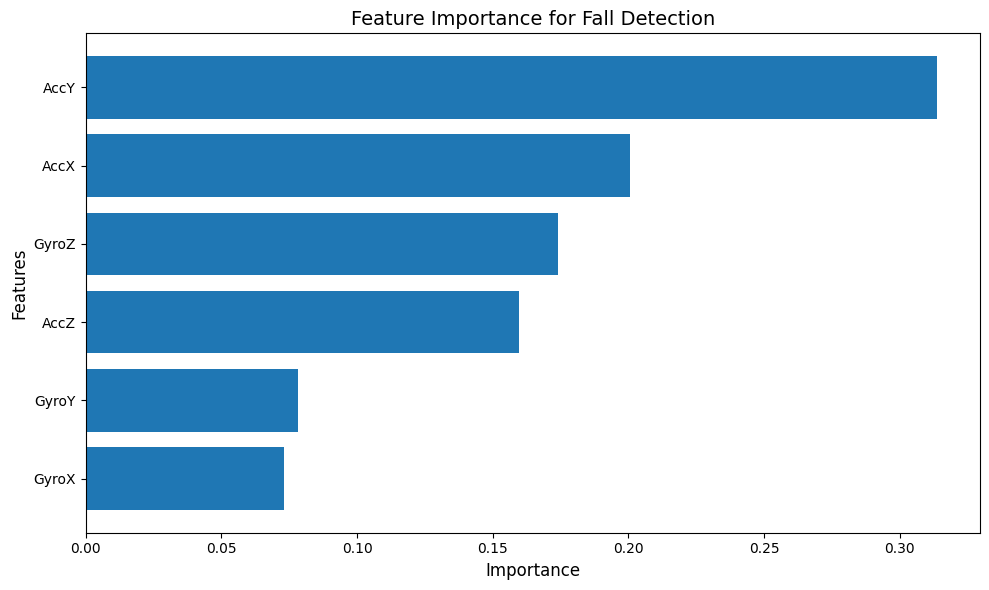


OVERFITTING ANALYSIS

📊 Train-Test Gaps:
   Accuracy Gap:  0.0078 (0.78%)
   Precision Gap: 0.0560 (5.60%)
   Recall Gap:    0.1004 (10.04%)

✅ EXCELLENT! Model generalizes very well (minimal overfitting)

FINAL VERDICT
✅ SUCCESS! Achieved >90% accuracy on TEST SET!
   Train Accuracy: 98.04%
   Test Accuracy:  97.26%
   Fall Detection Rate (Recall): 56.86%

MODEL SAVED FOR ESP32 DEPLOYMENT
✅ Model saved as: fall_detection_model.pkl
✅ Scaler saved as: scaler.pkl


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Files downloaded to your computer

TRAINING COMPLETE!


In [ ]:
# ============================================
# TRAINING MULTIPLE AI MODELS WITH TRAIN/TEST SEPARATION
# ============================================

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score, precision_score, recall_score
import warnings
warnings.filterwarnings('ignore')

# Load the dataset
df = pd.read_excel('fall_detection_dataset.xlsx')

print("="*70)
print("DATA PREPARATION FOR TRAINING")
print("="*70)

# Prepare features (X) and labels (y)
feature_columns = ['AccX', 'AccY', 'AccZ', 'GyroX', 'GyroY', 'GyroZ']
X = df[feature_columns].values
y = df['Label'].values

print(f"Total dataset shape: {X.shape}")
print(f"Total samples: {len(y)}")
print(f"\n📊 TOTAL DATASET CLASS DISTRIBUTION:")
print(f"   Normal (0): {(y==0).sum()} samples ({(y==0).sum()/len(y)*100:.2f}%)")
print(f"   Fall (1):   {(y==1).sum()} samples ({(y==1).sum()/len(y)*100:.2f}%)")

# Split data (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\n📊 TRAIN SET (80% of data):")
print(f"   Total samples: {X_train.shape[0]}")
print(f"   Normal (0): {(y_train==0).sum()} samples")
print(f"   Fall (1):   {(y_train==1).sum()} samples")

print(f"\n📊 TEST SET (20% of data):")
print(f"   Total samples: {X_test.shape[0]}")
print(f"   Normal (0): {(y_test==0).sum()} samples")
print(f"   Fall (1):   {(y_test==1).sum()} samples")

# Standardize features (important for SVM and Neural Network)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ============================================
# TRAIN DIFFERENT MODELS WITH TRAIN/TEST RESULTS
# ============================================

models = {
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42, n_estimators=100),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42),
    'SVM': SVC(kernel='rbf', random_state=42),
    'Neural Network': MLPClassifier(hidden_layer_sizes=(64, 32), random_state=42, max_iter=500)
}

print("\n" + "="*70)
print("TRAINING AND EVALUATING MODELS (TRAIN SET vs TEST SET)")
print("="*70)

results = []

for name, model in models.items():
    print(f"\n{'='*70}")
    print(f"📊 MODEL: {name}")
    print(f"{'='*70}")

    # Train the model
    if name in ['SVM', 'Neural Network']:
        model.fit(X_train_scaled, y_train)
        # Predict on TRAIN set
        y_train_pred = model.predict(X_train_scaled)
        # Predict on TEST set
        y_test_pred = model.predict(X_test_scaled)
    else:
        model.fit(X_train, y_train)
        # Predict on TRAIN set
        y_train_pred = model.predict(X_train)
        # Predict on TEST set
        y_test_pred = model.predict(X_test)

    # Calculate metrics for TRAIN set
    train_accuracy = accuracy_score(y_train, y_train_pred)
    train_f1 = f1_score(y_train, y_train_pred)
    train_precision = precision_score(y_train, y_train_pred)
    train_recall = recall_score(y_train, y_train_pred)

    # Calculate metrics for TEST set
    test_accuracy = accuracy_score(y_test, y_test_pred)
    test_f1 = f1_score(y_test, y_test_pred)
    test_precision = precision_score(y_test, y_test_pred)
    test_recall = recall_score(y_test, y_test_pred)

    # Store results
    results.append({
        'Model': name,
        'Train_Accuracy': train_accuracy,
        'Test_Accuracy': test_accuracy,
        'Train_F1': train_f1,
        'Test_F1': test_f1,
        'Train_Precision': train_precision,
        'Test_Precision': test_precision,
        'Train_Recall': train_recall,
        'Test_Recall': test_recall
    })

    # Print TRAIN SET results
    print(f"\n📈 TRAIN SET RESULTS:")
    print(f"   Accuracy:  {train_accuracy:.4f} ({train_accuracy*100:.2f}%)")
    print(f"   Precision: {train_precision:.4f} ({train_precision*100:.2f}%)")
    print(f"   Recall:    {train_recall:.4f} ({train_recall*100:.2f}%)")
    print(f"   F1-Score:  {train_f1:.4f}")

    # Print TEST SET results
    print(f"\n📉 TEST SET RESULTS:")
    print(f"   Accuracy:  {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")
    print(f"   Precision: {test_precision:.4f} ({test_precision*100:.2f}%)")
    print(f"   Recall:    {test_recall:.4f} ({test_recall*100:.2f}%)")
    print(f"   F1-Score:  {test_f1:.4f}")

    # Check for overfitting
    overfit_gap = train_accuracy - test_accuracy
    if overfit_gap > 0.1:
        print(f"\n⚠️ WARNING: Possible overfitting! (Train-Test gap: {overfit_gap:.4f})")
    else:
        print(f"\n✅ Good generalization! (Train-Test gap: {overfit_gap:.4f})")

# Create comparison dataframe
results_df = pd.DataFrame(results)
results_df = results_df.sort_values('Test_Accuracy', ascending=False)

print("\n" + "="*70)
print("MODEL COMPARISON SUMMARY (Sorted by TEST Accuracy)")
print("="*70)
print("\n{:<20} {:>12} {:>12} {:>12} {:>12}".format(
    'Model', 'Train Acc', 'Test Acc', 'Train F1', 'Test F1'
))
print("-"*70)
for _, row in results_df.iterrows():
    print("{:<20} {:>11.4f}% {:>11.4f}% {:>11.4f} {:>11.4f}".format(
        row['Model'][:18],
        row['Train_Accuracy']*100,
        row['Test_Accuracy']*100,
        row['Train_F1'],
        row['Test_F1']
    ))

# ============================================
# FIND BEST MODEL WITH HYPERPARAMETER TUNING
# ============================================

print("\n" + "="*70)
print("HYPERPARAMETER TUNING FOR BEST MODEL")
print("="*70)

# Random Forest usually works best for fall detection
rf = RandomForestClassifier(random_state=42)

# Define parameter grid
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [10, 20, 30, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# Grid search with cross-validation
grid_search = GridSearchCV(
    rf, param_grid, cv=5, scoring='accuracy', n_jobs=-1, verbose=1
)
grid_search.fit(X_train, y_train)

print(f"\n✅ Best parameters found: {grid_search.best_params_}")
print(f"✅ Best cross-validation accuracy: {grid_search.best_score_:.4f} ({grid_search.best_score_*100:.2f}%)")

# Evaluate best model on TRAIN and TEST sets
best_rf = grid_search.best_estimator_

# TRAIN set predictions
y_train_pred_best = best_rf.predict(X_train)
# TEST set predictions
y_test_pred_best = best_rf.predict(X_test)

# Calculate TRAIN metrics
train_best_accuracy = accuracy_score(y_train, y_train_pred_best)
train_best_f1 = f1_score(y_train, y_train_pred_best)
train_best_precision = precision_score(y_train, y_train_pred_best)
train_best_recall = recall_score(y_train, y_train_pred_best)

# Calculate TEST metrics
test_best_accuracy = accuracy_score(y_test, y_test_pred_best)
test_best_f1 = f1_score(y_test, y_test_pred_best)
test_best_precision = precision_score(y_test, y_test_pred_best)
test_best_recall = recall_score(y_test, y_test_pred_best)

print("\n" + "="*70)
print("BEST RANDOM FOREST MODEL - DETAILED RESULTS")
print("="*70)

print("\n📊 TRAIN SET RESULTS (Best Model):")
print(f"   Accuracy:  {train_best_accuracy:.4f} ({train_best_accuracy*100:.2f}%)")
print(f"   Precision: {train_best_precision:.4f} ({train_best_precision*100:.2f}%)")
print(f"   Recall:    {train_best_recall:.4f} ({train_best_recall*100:.2f}%)")
print(f"   F1-Score:  {train_best_f1:.4f}")

print("\n📊 TEST SET RESULTS (Best Model):")
print(f"   Accuracy:  {test_best_accuracy:.4f} ({test_best_accuracy*100:.2f}%)")
print(f"   Precision: {test_best_precision:.4f} ({test_best_precision*100:.2f}%)")
print(f"   Recall:    {test_best_recall:.4f} ({test_best_recall*100:.2f}%)")
print(f"   F1-Score:  {test_best_f1:.4f}")

# ============================================
# CONFUSION MATRICES (Train vs Test)
# ============================================

print("\n" + "="*70)
print("CONFUSION MATRICES - TRAIN SET vs TEST SET")
print("="*70)

# TRAIN SET Confusion Matrix
cm_train = confusion_matrix(y_train, y_train_pred_best)
tn_train, fp_train, fn_train, tp_train = cm_train.ravel()

print("\n📊 TRAIN SET CONFUSION MATRIX:")
print("                 Predicted")
print("               Normal   Fall")
print(f"Actual Normal    {tn_train:5d}   {fp_train:5d}")
print(f"       Fall       {fn_train:5d}   {tp_train:5d}")

# TEST SET Confusion Matrix
cm_test = confusion_matrix(y_test, y_test_pred_best)
tn_test, fp_test, fn_test, tp_test = cm_test.ravel()

print("\n📊 TEST SET CONFUSION MATRIX:")
print("                 Predicted")
print("               Normal   Fall")
print(f"Actual Normal    {tn_test:5d}   {fp_test:5d}")
print(f"       Fall       {fn_test:5d}   {tp_test:5d}")

# Calculate detailed metrics for both sets
train_sensitivity = tp_train / (tp_train + fn_train) if (tp_train + fn_train) > 0 else 0
train_specificity = tn_train / (tn_train + fp_train) if (tn_train + fp_train) > 0 else 0

test_sensitivity = tp_test / (tp_test + fn_test) if (tp_test + fn_test) > 0 else 0
test_specificity = tn_test / (tn_test + fp_test) if (tn_test + fp_test) > 0 else 0

print("\n📊 DETAILED METRICS COMPARISON:")
print("-"*70)
print(f"{'Metric':<20} {'TRAIN SET':>15} {'TEST SET':>15} {'Difference':>15}")
print("-"*70)
print(f"{'Accuracy':<20} {train_best_accuracy*100:>14.2f}% {test_best_accuracy*100:>14.2f}% {(train_best_accuracy-test_best_accuracy)*100:>14.2f}%")
print(f"{'Sensitivity (Fall)':<20} {train_sensitivity*100:>14.2f}% {test_sensitivity*100:>14.2f}% {(train_sensitivity-test_sensitivity)*100:>14.2f}%")
print(f"{'Specificity (Normal)':<20} {train_specificity*100:>14.2f}% {test_specificity*100:>14.2f}% {(train_specificity-test_specificity)*100:>14.2f}%")
print(f"{'Precision':<20} {train_best_precision*100:>14.2f}% {test_best_precision*100:>14.2f}% {(train_best_precision-test_best_precision)*100:>14.2f}%")
print(f"{'Recall':<20} {train_best_recall*100:>14.2f}% {test_best_recall*100:>14.2f}% {(train_best_recall-test_best_recall)*100:>14.2f}%")
print(f"{'F1-Score':<20} {train_best_f1*100:>14.2f}% {test_best_f1*100:>14.2f}% {(train_best_f1-test_best_f1)*100:>14.2f}%")

# ============================================
# FALL EVENT COUNT SUMMARY
# ============================================

print("\n" + "="*70)
print("FALL EVENT COUNT SUMMARY")
print("="*70)

print(f"\n📊 TOTAL DATASET:")
print(f"   Total Fall events: {(y==1).sum()}")
print(f"   Total Normal events: {(y==0).sum()}")

print(f"\n📊 TRAIN SET (80% of data):")
print(f"   Fall events: {(y_train==1).sum()}")
print(f"   Normal events: {(y_train==0).sum()}")
print(f"   Correctly predicted falls: {tp_train}")
print(f"   Missed falls (False Negatives): {fn_train}")
print(f"   False alarms (False Positives): {fp_train}")

print(f"\n📊 TEST SET (20% of data):")
print(f"   Fall events: {(y_test==1).sum()}")
print(f"   Normal events: {(y_test==0).sum()}")
print(f"   Correctly predicted falls: {tp_test}")
print(f"   Missed falls (False Negatives): {fn_test}")
print(f"   False alarms (False Positives): {fp_test}")

# ============================================
# CLASSIFICATION REPORT (Train vs Test)
# ============================================

print("\n" + "="*70)
print("CLASSIFICATION REPORT - TRAIN SET")
print("="*70)
print(classification_report(y_train, y_train_pred_best, target_names=['Normal (0)', 'Fall (1)']))

print("\n" + "="*70)
print("CLASSIFICATION REPORT - TEST SET")
print("="*70)
print(classification_report(y_test, y_test_pred_best, target_names=['Normal (0)', 'Fall (1)']))

# ============================================
# FEATURE IMPORTANCE
# ============================================

print("\n" + "="*70)
print("FEATURE IMPORTANCE (Based on Best Random Forest Model)")
print("="*70)

feature_importance = pd.DataFrame({
    'Feature': feature_columns,
    'Importance': best_rf.feature_importances_
}).sort_values('Importance', ascending=False)

print(feature_importance.to_string(index=False))

# Plot feature importance
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
plt.barh(feature_importance['Feature'], feature_importance['Importance'])
plt.xlabel('Importance', fontsize=12)
plt.ylabel('Features', fontsize=12)
plt.title('Feature Importance for Fall Detection', fontsize=14)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('feature_importance.png')
plt.show()

# ============================================
# OVERFITTING CHECK
# ============================================

print("\n" + "="*70)
print("OVERFITTING ANALYSIS")
print("="*70)

accuracy_gap = train_best_accuracy - test_best_accuracy
precision_gap = train_best_precision - test_best_precision
recall_gap = train_best_recall - test_best_recall

print(f"\n📊 Train-Test Gaps:")
print(f"   Accuracy Gap:  {accuracy_gap:.4f} ({accuracy_gap*100:.2f}%)")
print(f"   Precision Gap: {precision_gap:.4f} ({precision_gap*100:.2f}%)")
print(f"   Recall Gap:    {recall_gap:.4f} ({recall_gap*100:.2f}%)")

if accuracy_gap < 0.05:
    print("\n✅ EXCELLENT! Model generalizes very well (minimal overfitting)")
elif accuracy_gap < 0.1:
    print("\n👍 GOOD! Model generalizes well (acceptable overfitting)")
elif accuracy_gap < 0.15:
    print("\n⚠️ MODERATE OVERFITTING detected. Consider simplifying the model.")
else:
    print("\n❌ SEVERE OVERFITTING detected! Model is memorizing training data.")

# ============================================
# FINAL VERDICT
# ============================================

print("\n" + "="*70)
print("FINAL VERDICT")
print("="*70)

if test_best_accuracy >= 0.90:
    print("✅ SUCCESS! Achieved >90% accuracy on TEST SET!")
    print(f"   Train Accuracy: {train_best_accuracy*100:.2f}%")
    print(f"   Test Accuracy:  {test_best_accuracy*100:.2f}%")
    print(f"   Fall Detection Rate (Recall): {test_best_recall*100:.2f}%")
else:
    print(f"⚠️ Current Test Accuracy: {test_best_accuracy*100:.2f}%")
    print("   Suggestions to improve:")
    print("   1. Add more training data")
    print("   2. Use windowed sequences instead of single points")
    print("   3. Try adding rolling averages of sensor data")
    print("   4. Reduce model complexity to prevent overfitting")

# ============================================
# MODEL SAVING FOR ESP32 DEPLOYMENT
# ============================================

print("\n" + "="*70)
print("MODEL SAVED FOR ESP32 DEPLOYMENT")
print("="*70)

# Save the best model
import joblib
joblib.dump(best_rf, 'fall_detection_model.pkl')
joblib.dump(scaler, 'scaler.pkl')

print("✅ Model saved as: fall_detection_model.pkl")
print("✅ Scaler saved as: scaler.pkl")

# Download model files (for Google Colab)
try:
    from google.colab import files
    files.download('fall_detection_model.pkl')
    files.download('scaler.pkl')
    print("✅ Files downloaded to your computer")
except:
    print("⚠️ Not running in Colab - files saved locally")

print("\n" + "="*70)
print("TRAINING COMPLETE!")
print("="*70)

In [ ]:
# ============================================
# CONVERT RANDOM FOREST MODEL TO C++ CODE FOR ESP32
# ============================================

import joblib
import numpy as np
import pandas as pd

# Load your trained model
model = joblib.load('fall_detection_model.pkl')
scaler = joblib.load('scaler.pkl')

print("="*60)
print("CONVERTING MODEL TO C++ FOR ESP32")
print("="*60)

# Get model parameters
n_trees = len(model.estimators_)
n_features = model.n_features_in_
feature_names = ['accel_x', 'accel_y', 'accel_z', 'gyro_x', 'gyro_y', 'gyro_z']

print(f"Number of trees: {n_trees}")
print(f"Number of features: {n_features}")

# Extract all tree details
trees_data = []
for i, tree in enumerate(model.estimators_):
    tree_data = {
        'left_child': tree.tree_.children_left.tolist(),
        'right_child': tree.tree_.children_right.tolist(),
        'feature': tree.tree_.feature.tolist(),
        'threshold': tree.tree_.threshold.tolist(),
        'value': tree.tree_.value.tolist(),
        'n_nodes': tree.tree_.node_count
    }
    trees_data.append(tree_data)

# Generate C++ header file
cpp_code = """// ============================================
// FALL DETECTION MODEL FOR ESP32
// Generated from trained Random Forest model
// ============================================

#ifndef FALL_DETECTION_MODEL_H
#define FALL_DETECTION_MODEL_H

#include <Arduino.h>

class FallDetectionModel {
private:
    // Number of trees in the forest
    static const int NUM_TREES = """ + str(n_trees) + """;
    static const int NUM_FEATURES = """ + str(n_features) + """;

"""

# Add tree structures
for tree_idx, tree in enumerate(trees_data):
    cpp_code += f"""
    // Tree {tree_idx + 1}
    static const int LEFT_CHILD_{tree_idx + 1}[] = {tree['left_child']};
    static const int RIGHT_CHILD_{tree_idx + 1}[] = {tree['right_child']};
    static const int FEATURE_{tree_idx + 1}[] = {tree['feature']};
    static const float THRESHOLD_{tree_idx + 1}[] = {tree['threshold']};
    static const float VALUE_{tree_idx + 1}[][2] = {tree['value']};
    static const int N_NODES_{tree_idx + 1} = {tree['n_nodes']};
"""

cpp_code += """
public:
    // Predict using Random Forest
    static int predict(float features[]) {
        float sum = 0.0;

"""

# Add prediction code for each tree
for tree_idx in range(n_trees):
    cpp_code += f"""
        // Tree {tree_idx + 1} prediction
        int node = 0;
        while (LEFT_CHILD_{tree_idx + 1}[node] != -1) {{
            int feat_idx = FEATURE_{tree_idx + 1}[node];
            if (features[feat_idx] <= THRESHOLD_{tree_idx + 1}[node]) {{
                node = LEFT_CHILD_{tree_idx + 1}[node];
            }} else {{
                node = RIGHT_CHILD_{tree_idx + 1}[node];
            }}
        }}
        if (VALUE_{tree_idx + 1}[node][1] > VALUE_{tree_idx + 1}[node][0]) {{
            sum += 1.0;
        }}
"""

cpp_code += """

        // Return 1 if more than half the trees vote for fall
        return (sum > (NUM_TREES / 2.0)) ? 1 : 0;
    }

    // Get feature names
    static const char** getFeatureNames() {
        static const char* names[] = {"""
for name in feature_names:
    cpp_code += f'"{name}", '
cpp_code = cpp_code.rstrip(', ') + """};
        return names;
    }
};

#endif // FALL_DETECTION_MODEL_H
"""

# Save the C++ header file
with open('fall_detection_model.h', 'w') as f:
    f.write(cpp_code)

print("\n✅ C++ header file generated: fall_detection_model.h")

# Also generate scaler parameters for normalization
scaler_code = """// ============================================
// SCALER PARAMETERS FOR FEATURE NORMALIZATION
// ============================================

#ifndef SCALER_PARAMS_H
#define SCALER_PARAMS_H

#include <Arduino.h>

class ScalerParams {
public:
    static const int NUM_FEATURES = """ + str(n_features) + """;

    // Mean values for each feature
    static const float MEAN[];

    // Standard deviation values for each feature
    static const float STD[];

    // Normalize feature array
    static void normalize(float features[], float normalized[]) {
        for(int i = 0; i < NUM_FEATURES; i++) {
            normalized[i] = (features[i] - MEAN[i]) / STD[i];
        }
    }
};

"""
# Add mean and std values
scaler_code += f"\nconst float ScalerParams::MEAN[{n_features}] = {{"
for i, col in enumerate(feature_names):
    mean_val = scaler.mean_[i] if hasattr(scaler, 'mean_') else 0
    scaler_code += f"{mean_val:.6f}, "
scaler_code = scaler_code.rstrip(', ') + "};\n\n"

scaler_code += f"const float ScalerParams::STD[{n_features}] = {{"
for i, col in enumerate(feature_names):
    scale_val = scaler.scale_[i] if hasattr(scaler, 'scale_') else 1
    scaler_code += f"{scale_val:.6f}, "
scaler_code = scaler_code.rstrip(', ') + "};\n\n#endif"

with open('scaler_params.h', 'w') as f:
    f.write(scaler_code)

print("✅ Scaler parameters file generated: scaler_params.h")

# Download files
from google.colab import files
files.download('fall_detection_model.h')
files.download('scaler_params.h')

print("\n✅ Download complete! Save these .h files for ESP32.")

CONVERTING MODEL TO C++ FOR ESP32
Number of trees: 50
Number of features: 6

✅ C++ header file generated: fall_detection_model.h
✅ Scaler parameters file generated: scaler_params.h


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


✅ Download complete! Save these .h files for ESP32.
